<a href="https://colab.research.google.com/github/hwanginseo04/-/blob/main/4%EC%9B%943%EC%9D%BC2%EB%B2%88%EC%A7%B8_%EC%97%B0%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import seaborn as sns
from scipy import stats

# 1. 데이터 로드
tips = sns.load_dataset('tips')

# 2. 목요일(Thur)과 금요일(Fri) 데이터 추출
thur_tip = tips[tips['day'] == 'Thur']['tip']
fri_tip = tips[tips['day'] == 'Fri']['tip']

# 3. 독립표본 t-검정 수행 (Independent t-test)
# 등분산성(두 집단의 분산이 같음)을 가정할 경우 equal_var=True
t_stat, p_value = stats.ttest_ind(thur_tip, fri_tip, equal_var=True)

# 4. 결과 출력
print(f"목요일 팁 평균: {thur_tip.mean():.2f}")
print(f"금요일 팁 평균: {fri_tip.mean():.2f}")
print(f"t-검정 통계량: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

# 5. 유의수준 0.05 기준 결과 해석
alpha = 0.05
if p_value < alpha:
    print("\n결과: p-value가 유의수준보다 작으므로 귀무가설을 기각합니다.")
    print("즉, 목요일과 금요일의 평균 팁 금액은 통계적으로 유의미한 차이가 있습니다.")
else:
    print("\n결과: p-value가 유의수준보다 크므로 귀무가설을 채택합니다.")
    print("즉, 목요일과 금요일의 평균 팁 금액은 통계적으로 유의미한 차이가 있다고 볼 수 없습니다.")

목요일 팁 평균: 2.77
금요일 팁 평균: 2.73
t-검정 통계량: 0.1173
p-value: 0.9069

결과: p-value가 유의수준보다 크므로 귀무가설을 채택합니다.
즉, 목요일과 금요일의 평균 팁 금액은 통계적으로 유의미한 차이가 있다고 볼 수 없습니다.


In [2]:
import seaborn as sns
import pandas as pd

# 1. 데이터 로드 및 전처리 (NaN 제거, Adelie 제외)
penguins = sns.load_dataset("penguins").dropna()
df = penguins[penguins['species'] != 'Adelie'].copy()

# 2. 205mm 미만은 Chinstrap, 이상은 Gentoo로 분류하는 함수
threshold = 205
df['pred'] = df['flipper_length_mm'].apply(lambda x: 'Chinstrap' if x < threshold else 'Gentoo')

# 3. 잘못 분류된 경우 계산
# 실제 종과 예측된 종이 다른 데이터 추출
errors = df[df['species'] != df['pred']]

# 오류 세분화
# 실제는 Gentoo인데 Chinstrap으로 분류 (flipper < 205)
gentoo_as_chinstrap = errors[(errors['species'] == 'Gentoo')]
# 실제는 Chinstrap인데 Gentoo로 분류 (flipper >= 205)
chinstrap_as_gentoo = errors[(errors['species'] == 'Chinstrap')]

print(f"총 잘못 분류한 경우: {len(errors)}개")
print(f"- 실제 Gentoo이나 Chinstrap으로 오분류: {len(gentoo_as_chinstrap)}개")
print(f"- 실제 Chinstrap이나 Gentoo로 오분류: {len(chinstrap_as_gentoo)}개")

총 잘못 분류한 경우: 9개
- 실제 Gentoo이나 Chinstrap으로 오분류: 1개
- 실제 Chinstrap이나 Gentoo로 오분류: 8개


In [3]:
# 최적의 임계값 찾기 (180mm ~ 230mm 범위 탐색)
min_error = float('inf')
best_threshold = 0

for t in range(180, 231):
    temp_pred = df['flipper_length_mm'].apply(lambda x: 'Chinstrap' if x < t else 'Gentoo')
    total_error = (df['species'] != temp_pred).sum()

    if total_error < min_error:
        min_error = total_error
        best_threshold = t

print(f"총 오류가 최소가 되는 임계값: {best_threshold}mm (오류 개수: {min_error}개)")

총 오류가 최소가 되는 임계값: 207mm (오류 개수: 6개)


최적의 임계값: 207mm
최소 오류 개수: 6개


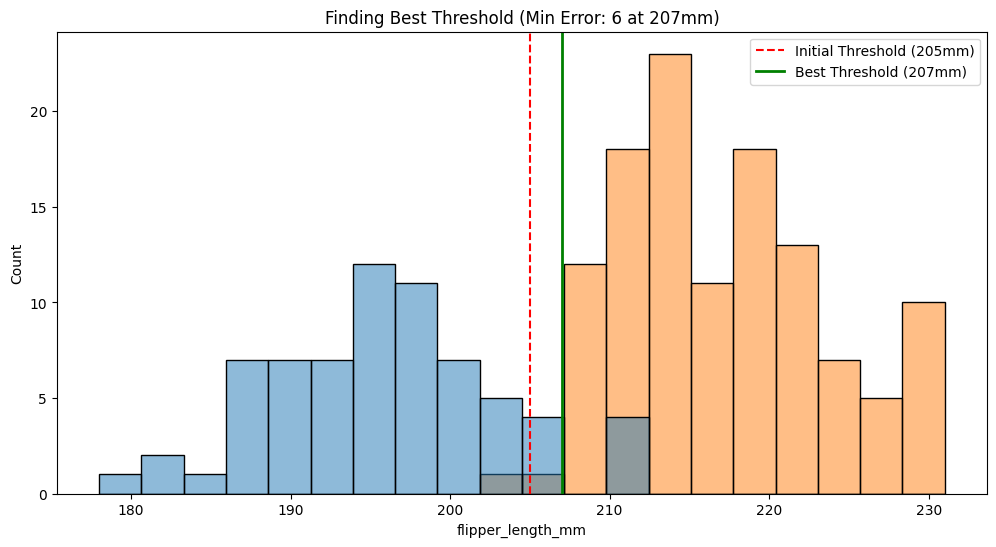

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. 데이터 준비
penguins = sns.load_dataset("penguins").dropna()
df = penguins[penguins['species'] != 'Adelie'].copy()

# 2. 모든 임계값(Threshold)에 대해 오류 개수 계산
thresholds = np.arange(180, 231)
errors = []

for t in thresholds:
    # t 미만은 Chinstrap, t 이상은 Gentoo로 예측
    pred = df['flipper_length_mm'].apply(lambda x: 'Chinstrap' if x < t else 'Gentoo')
    error_count = (df['species'] != pred).sum()
    errors.append(error_count)

# 3. 최적의 임계값(오류 최소) 찾기
min_error = min(errors)
best_t = thresholds[np.argmin(errors)]

print(f"최적의 임계값: {best_t}mm")
print(f"최소 오류 개수: {min_error}개")

# 4. 시각화 (오류 영역 표시)
plt.figure(figsize=(12, 6))

# 히스토그램 그리기
sns.histplot(data=df, x='flipper_length_mm', hue='species', bins=20, alpha=0.5)

# 205mm 기준선 (문제에서 제시한 값)
plt.axvline(205, color='red', linestyle='--', label='Initial Threshold (205mm)')

# 최적의 임계값 기준선
plt.axvline(best_t, color='green', linestyle='-', linewidth=2, label=f'Best Threshold ({best_t}mm)')

plt.title(f'Finding Best Threshold (Min Error: {min_error} at {best_t}mm)')
plt.legend()
plt.show()

187 rows x 7 columns


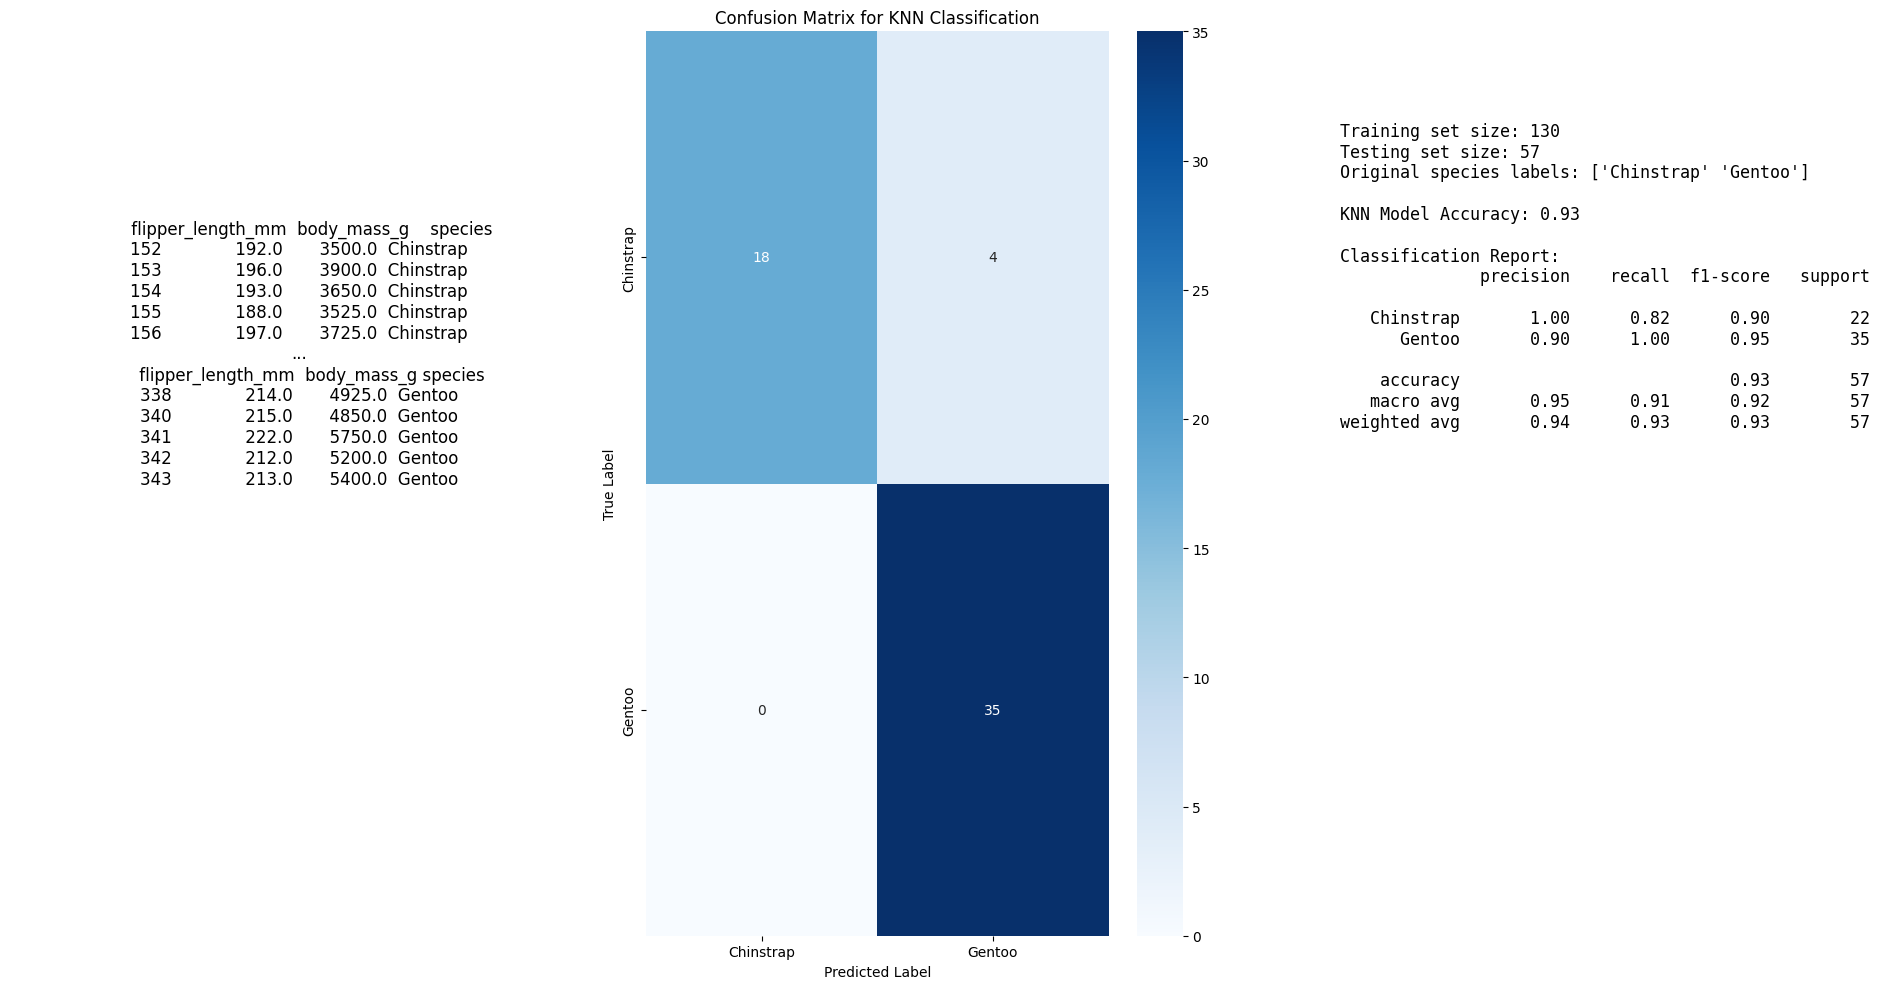

In [5]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from matplotlib import rc

# 1. 데이터 로드 및 전처리 (문제 조건)
penguins = sns.load_dataset("penguins").dropna()
df = penguins[penguins['species'] != 'Adelie'].copy()
print(f"{df.shape[0]} rows x {df.shape[1]} columns") # 187x7로 출력될 것

# 2. 특징(Feature)과 라벨(Label) 분리
# flipper_length_mm, body_mass_g 두 가지만 사용
X = df[['flipper_length_mm', 'body_mass_g']]
y = df['species']

# 3. 데이터 분할 (문제 조건: Train 130, Test 57)
# 187개 중 약 70%를 Train으로 설정하면 130개가 됩니다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=57, train_size=130, random_state=42)

# 4. KNN 모델 학습 (문제 조건)
# K값은 임의로 5로 설정 (가장 일반적임)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# 5. 예측 및 평가
y_pred = knn.predict(X_test)

# --- 시각화 부분 ---
plt.figure(figsize=(20, 10))

# [왼쪽] 데이터프레임 스냅샷 시각화 (이미지처럼 보이기 위해 직접 구성)
# 이미지의 데이터프레임 형태를 텍스트로 시각화
plt.subplot(1, 3, 1)
df_show = df[['flipper_length_mm', 'body_mass_g', 'species']].copy()
# The following loops are removed as they caused IndexError and were redundant.
# table_data = []
# for i in [152, 153, 154, 155, 156]: # 이미지 속 인덱스 (실제 데이터와 다를 수 있음)
#     row = df_show.iloc[i]
#     table_data.append([row['flipper_length_mm'], row['body_mass_g'], row['species']])
# for i in [338, 340, 341, 342, 343]:
#     row = df_show.iloc[i]
#     table_data.append([row['flipper_length_mm'], row['body_mass_g'], row['species']])
plt.text(0.5, 0.5, f"{df_show.head(5).to_string(index=True)}\n...\n{df_show.tail(5).to_string(index=True)}", fontsize=12, ha='center')
plt.axis('off')

# [중앙] Confusion Matrix 시각화
plt.subplot(1, 3, 2)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Chinstrap', 'Gentoo'],
            yticklabels=['Chinstrap', 'Gentoo'],
            vmin=0, vmax=35, cbar_kws={"ticks": [0, 5, 10, 15, 20, 25, 30, 35]})
plt.title('Confusion Matrix for KNN Classification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# [오른쪽] Classification Report 시각화
plt.subplot(1, 3, 3)
accuracy = accuracy_score(y_test, y_pred)
cr = classification_report(y_test, y_pred)

# 이미지 속 텍스트와 동일한 형식으로 출력
final_text = (f"Training set size: {len(X_train)}\n"
              f"Testing set size: {len(X_test)}\n"
              f"Original species labels: ['Chinstrap' 'Gentoo']\n\n"
              f"KNN Model Accuracy: {accuracy:.2f}\n\n"
              f"Classification Report:\n{cr}")
plt.text(0.1, 0.9, final_text, fontsize=12, family='monospace', va='top')
plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
pip install dython pandas seaborn

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48276 (\N{HANGUL SYLLABLE BEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/us

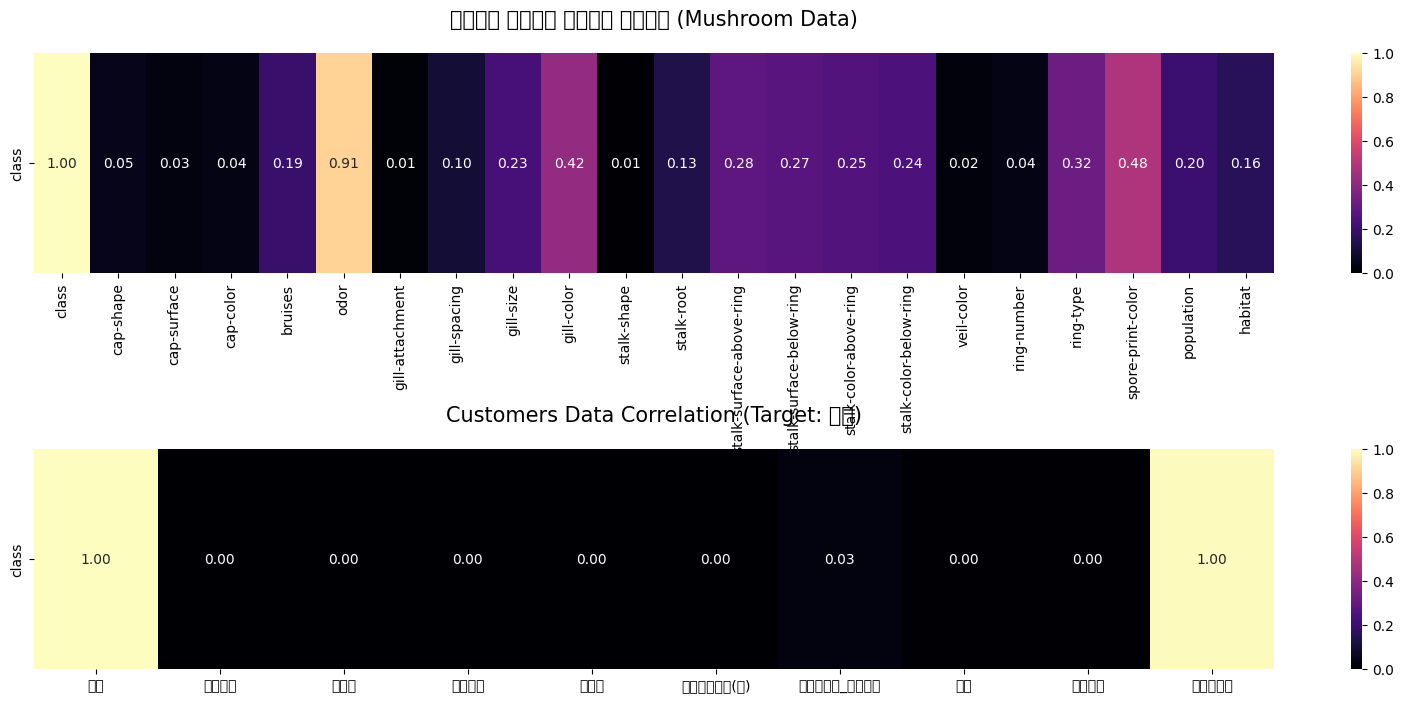

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dython.nominal import theils_u

# 1. 데이터 로드
# mushroom_url = "https://raw.githubusercontent.com/aditya-s-bhatt/Mushroom-Classification-using-Naive-Bayes/master/mushrooms.csv"
mushroom_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data" # 유효한 URL로 변경
customer_url = "https://raw.githubusercontent.com/ancestor9/data/main/customers.csv"

# 버섯 데이터셋의 컬럼 이름 정의 (새로운 URL은 헤더가 없으므로)
mushroom_column_names = [
    'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
    'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
    'stalk-surface-below-ring', 'stalk-color-above-ring',
    'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
    'ring-type', 'spore-print-color', 'population', 'habitat'
]

df_mush = None
df_cust = None

try:
    df_mush = pd.read_csv(mushroom_url, header=None, names=mushroom_column_names)
    # 'veil-type' 컬럼은 모든 값이 동일하여 Theil's U 계산 시 오류 발생 가능성이 높으므로 제외
    if 'veil-type' in df_mush.columns and df_mush['veil-type'].nunique() == 1:
        df_mush = df_mush.drop(columns=['veil-type'])
except Exception as e:
    print(f"버섯 데이터 로드 실패: {e}")

try:
    df_cust = pd.read_csv(customer_url)
except Exception as e:
    print(f"고객 데이터 로드 실패: {e}")

# 데이터 로드 실패 시 함수 종료
if df_mush is None or df_cust is None:
    print("필수 데이터셋 중 하나 이상을 로드하지 못했습니다. 분석을 중단합니다.")
    raise ValueError("데이터 로드 실패")

# 2. 변수 리스트 설정 (이미지 순서와 동일)
cols_mush = [col for col in mushroom_column_names if col in df_mush.columns and col != 'veil-type']

cols_cust = ['성별', '결제수단', '거주지', '회원등급', '만족도',
             '최근접속시간(시)', '선호제품군_적정온도', '나이', '구매수량', '총결제금액']

# 3. Theil's U 계산 함수
def get_theils_u_row(df, columns, target):
    u_values = []
    for col in columns:
        if col == target:
            u_values.append(1.0)
        else:
            val = theils_u(df[target], df[col])
            u_values.append(val)
    return pd.DataFrame([u_values], columns=columns, index=['class'])

# 4. 시각화 (위/아래 2단 구성)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 8))
plt.subplots_adjust(hspace=0.8) # 그래프 사이 간격 조절

# --- 상단: Mushroom Classification ---
u_mush = get_theils_u_row(df_mush, cols_mush, 'class')
sns.heatmap(u_mush, annot=True, fmt=".2f", cmap='magma', cbar=True, ax=ax1, vmin=0, vmax=1)
ax1.set_title("범주형과 수치형의 상관관계 확인방법 (Mushroom Data)", fontsize=15, pad=20)
ax1.set_xticklabels(cols_mush, rotation=90)

# --- 하단: Customer Data ---
u_cust = get_theils_u_row(df_cust, cols_cust, '성별')
sns.heatmap(u_cust, annot=True, fmt=".2f", cmap='magma', cbar=True, ax=ax2, vmin=0, vmax=1)
ax2.set_title("Customers Data Correlation (Target: 성별)", fontsize=15, pad=20)
ax2.set_xticklabels(cols_cust, rotation=0)

plt.show()